Reason for Excluding CLASIFFICATION_FINAL

CLASIFFICATION_FINAL was excluded to reduce the possibility of data leakage and to make the model more practically usable. In a real-world prediction setting, the model should rely only on patient-related and clinical input attributes that are directly available at the time of prediction. Excluding this feature makes the ANN more defensible, transparent, and suitable for academic evaluation.

The ANN model is designed as a multilayer feedforward neural network for predicting the binary target variable DIED. After preprocessing, the model receives the selected patient and clinical attributes as input. A dense architecture with three hidden layers is proposed, using 64, 32, and 16 neurons respectively. ReLU activation is used in the hidden layers to capture nonlinear relationships among the features, while a sigmoid activation function is used in the output layer to generate a probability score for death prediction. Dropout layers are added after the first and second hidden layers to reduce overfitting and improve generalization.

The ANN model will be trained as a binary classification model using binary cross-entropy loss and the Adam optimizer. A batch size of 256 and a maximum of 30 epochs are selected to ensure stable and efficient training on the large dataset. Early stopping will be used to prevent overfitting by monitoring validation performance and restoring the best model weights. Since the target variable DIED is imbalanced, class weights will be applied during training so that the minority class receives appropriate importance.

The model will be evaluated using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrix, and loss curves. Among these, recall and F1-score will be given higher importance because the project focuses on identifying mortality risk, and the dataset contains significantly fewer death cases than survival cases.

The ANN implementation begins with loading the cleaned dataset and defining DIED as the binary target variable. The selected 16 input features are then separated by type, and the dataset is split into training, validation, and test sets using stratified sampling. Preprocessing is applied in a leakage-free manner, including scaling of AGE and encoding of MEDICAL_UNIT, while binary features are retained in their existing format. Because the dataset is imbalanced, class weights are applied during training.

A feedforward ANN with three hidden layers is then trained using binary cross-entropy loss and the Adam optimizer. Early stopping is used to prevent overfitting and preserve the best-performing model. Performance is assessed using accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrix, with greater emphasis on recall and F1-score due to the healthcare risk context. Final evaluation is performed only once on the test set, and the results are documented using metric tables and performance curves.

The preprocessing stage begins by separating the selected 16 input features from the binary target variable DIED. The features are categorized into binary, numerical, and categorical groups. A stratified split is then performed to create training, validation, and test sets in a 70:15:15 ratio while preserving the class distribution of the target variable.

Among the input features, AGE is treated as a numerical variable and standardized, while MEDICAL_UNIT is handled as a categorical variable and one-hot encoded. The remaining binary features are retained in their original 0/1 format. To prevent data leakage, all preprocessing transformations are fitted only on the training set and then applied unchanged to the validation and test sets. Since the target variable is imbalanced, class weights are computed using only the training labels and used during ANN training.

----------------------
----------------------

# ANN Model Building

## Step 1: Data Loading, Feature Selection, and Stratified Splitting

In this step, we load the cleaned COVID-19 dataset, finalize the ANN input features, lock `DIED` as the target variable, and create reproducible train, validation, and test splits.

### Final Modeling Setup

- **Target variable:** `DIED`
- **Excluded feature:** `CLASIFFICATION_FINAL`
- **Input features:** 
  `USMER`, `MEDICAL_UNIT`, `SEX`, `PATIENT_TYPE`, `PNEUMONIA`, `AGE`, 
  `DIABETES`, `COPD`, `ASTHMA`, `INMSUPR`, `HIPERTENSION`, 
  `OTHER_DISEASE`, `CARDIOVASCULAR`, `OBESITY`, 
  `RENAL_CHRONIC`, `TOBACCO`

- **Split strategy:** Stratified `70%` training, `15%` validation, `15%` test

### Importing the necessary Libraries

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [3]:
FEATURE_COLUMNS = [
    'USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE',
    'PNEUMONIA', 'AGE', 'DIABETES', 'COPD', 'ASTHMA',
    'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE',
    'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO'
]

TARGET_COLUMN = 'DIED'
RANDOM_STATE = 42

### Load & Validate Data

In [5]:
df = pd.read_csv(r'D:\Covid-19-Mexico-Dataset-Analysis\Data/Cleaned_CovidData.csv')

required_columns = FEATURE_COLUMNS + [TARGET_COLUMN]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f'Missing columns: {missing_columns}')

print('Dataset shape:', df.shape)
print('Total missing values:', int(df[required_columns].isnull().sum().sum()))

print('\nTarget distribution:')
print(df[TARGET_COLUMN].value_counts().sort_index())

Dataset shape: (1024829, 18)
Total missing values: 0

Target distribution:
DIED
0    950217
1     74612
Name: count, dtype: int64


### Train/Val/Test Split

In [6]:
X = df[FEATURE_COLUMNS].copy()
y = df[TARGET_COLUMN].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

train_df = X_train.copy()
train_df[TARGET_COLUMN] = y_train.to_numpy()

validation_df = X_val.copy()
validation_df[TARGET_COLUMN] = y_val.to_numpy()

test_df = X_test.copy()
test_df[TARGET_COLUMN] = y_test.to_numpy()

### Preprocessing

In [7]:
binary_features = [
    'USMER',
    'SEX',
    'PATIENT_TYPE',
    'PNEUMONIA',
    'DIABETES',
    'COPD',
    'ASTHMA',
    'INMSUPR',
    'HIPERTENSION',
    'OTHER_DISEASE',
    'CARDIOVASCULAR',
    'OBESITY',
    'RENAL_CHRONIC',
    'TOBACCO'
]

numerical_features = ['AGE']
categorical_features = ['MEDICAL_UNIT']

print("Binary features:", len(binary_features))
print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Binary features: 14
Numerical features: ['AGE']
Categorical features: ['MEDICAL_UNIT']


In [8]:
# Step 2.2: Build the preprocessing pipeline

try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', encoder, categorical_features),
        ('bin', 'passthrough', binary_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully.")


Preprocessing completed successfully.


In [9]:
# Step 2.3: Inspect transformed data

feature_names = preprocessor.get_feature_names_out()

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)
print("Processed feature count:", len(feature_names))

pd.DataFrame({
    'Processed_Feature_Name': feature_names
}).head(30)


Processed training shape: (717380, 28)
Processed validation shape: (153724, 28)
Processed test shape: (153725, 28)
Processed feature count: 28


,Processed_Feature_Name
0,num__AGE
1,cat__MEDICAL_UNIT_1
2,cat__MEDICAL_UNIT_2
3,cat__MEDICAL_UNIT_3
4,cat__MEDICAL_UNIT_4
5,cat__MEDICAL_UNIT_5
6,cat__MEDICAL_UNIT_6
7,cat__MEDICAL_UNIT_7
8,cat__MEDICAL_UNIT_8
9,cat__MEDICAL_UNIT_9


In [10]:
# Step 2.4: Convert data type for TensorFlow compatibility

X_train_processed = X_train_processed.astype('float32')
X_val_processed = X_val_processed.astype('float32')
X_test_processed = X_test_processed.astype('float32')

y_train_array = y_train.to_numpy(dtype='float32')
y_val_array = y_val.to_numpy(dtype='float32')
y_test_array = y_test.to_numpy(dtype='float32')

print(X_train_processed.dtype, y_train_array.dtype)


float32 float32


In [11]:
# Step 2.5: Compute class weights from the training set only

classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = {
    0: float(weights[0]),
    1: float(weights[1])
}

print("Class weights:", class_weight_dict)


Class weights: {0: 0.53926019917252, 1: 6.8677720762809225}


In the preprocessing stage, the selected input features were grouped into binary, numerical, and categorical types. The binary features were retained in their original 0/1 form, the numerical feature AGE was standardized, and the categorical feature MEDICAL_UNIT was transformed using one-hot encoding. To prevent data leakage, the preprocessing pipeline was fitted only on the training data and then applied unchanged to the validation and test sets. Since the target variable DIED was imbalanced, class weights were computed using only the training labels so that the ANN could give appropriate importance to the minority class during training.

-------
-----

## Step 3: building and compiling the ANN model

In [12]:
# Step 3.1: Set random seed and define the ANN architecture

tf.keras.utils.set_random_seed(42)

input_dim = X_train_processed.shape[1]

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation='relu'),
    Dropout(0.30),
    Dense(32, activation='relu'),
    Dropout(0.20),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

print("Input dimension:", input_dim)


Input dimension: 28


In [13]:
# Step 3.2: Compile the ANN model

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)


In [14]:
# Step 3.3: View model summary

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,481 (17.50 KB)

 Non-trainable params: 0 (0.00 B)

In this step, a feedforward Artificial Neural Network was constructed for the binary classification task of predicting the target variable DIED. The model architecture consisted of an input layer followed by three dense hidden layers containing 64, 32, and 16 neurons respectively. ReLU activation was used in the hidden layers to capture nonlinear relationships in the input data, while a sigmoid activation function was used in the output layer to produce a probability value for the binary outcome.

To reduce overfitting, dropout layers with rates of 0.30 and 0.20 were added after the first and second hidden layers. The model was compiled using the Adam optimizer with a learning rate of 0.001 and binary cross-entropy as the loss function. During training, the model was configured to monitor accuracy, precision, recall, and AUC.

------------
------------

### step 4: training the ANN with early stopping, validation monitoring, and class weights.

In [15]:
!pip install mlflow

In [16]:
# Step 4.1: MLflow and training setup

import mlflow
import matplotlib.pyplot as plt

from pathlib import Path
from tensorflow.keras.callbacks import EarlyStopping

PROJECT_DIR = Path("D:/Covid-19-Mexico-Dataset-Analysis")

TRAINING_ARTIFACT_DIR = PROJECT_DIR / "Model" / "artifacts" / "step4_training"
MLFLOW_TRACKING_DIR = PROJECT_DIR / "Model" / "mlruns"

TRAINING_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MLFLOW_TRACKING_DIR.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(MLFLOW_TRACKING_DIR.resolve().as_uri())
mlflow.set_experiment("Covid_ANN_DIED_Prediction")

BATCH_SIZE = 256
EPOCHS = 30
PATIENCE = 5

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

print("Project directory:", PROJECT_DIR)
print("Training artifact directory:", TRAINING_ARTIFACT_DIR)
print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Experiment name: Covid_ANN_DIED_Prediction")


Project directory: D:\Covid-19-Mexico-Dataset-Analysis
Training artifact directory: D:\Covid-19-Mexico-Dataset-Analysis\Model\artifacts\step4_training
MLflow tracking URI: file:///D:/Covid-19-Mexico-Dataset-Analysis/Model/mlruns
Experiment name: Covid_ANN_DIED_Prediction


c:\Users\rohit\anaconda3\envs\annvenv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


Epoch 1/30
2803/2803 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.8684 - auc: 0.9491 - loss: 0.2609 - precision: 0.3509 - recall: 0.9505 - val_accuracy: 0.8812 - val_auc: 0.9557 - val_loss: 0.2536 - val_precision: 0.3756 - val_recall: 0.9525
Epoch 2/30
2803/2803 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8765 - auc: 0.9529 - loss: 0.2459 - precision: 0.3665 - recall: 0.9550 - val_accuracy: 0.8833 - val_auc: 0.9558 - val_loss: 0.2485 - val_precision: 0.3795 - val_recall: 0.9504
Epoch 3/30
2803/2803 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8783 - auc: 0.9538 - loss: 0.2435 - precision: 0.3697 - recall: 0.9535 - val_accuracy: 0.8848 - val_auc: 0.9559 - val_loss: 0.2454 - val_precision: 0.3826 - val_recall: 0.9493
Epoch 4/30
2803/2803 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8784 - auc: 0.9542 - loss: 0.2422 - precision: 0.3701 - recall: 0.9544 - val_accuracy: 0.8830 - val_auc: 0.9559 - val_loss: 0.2445 - val_precision: 0.3790 - val_recall: 0.9515
Epoch 5/30
2803/2803

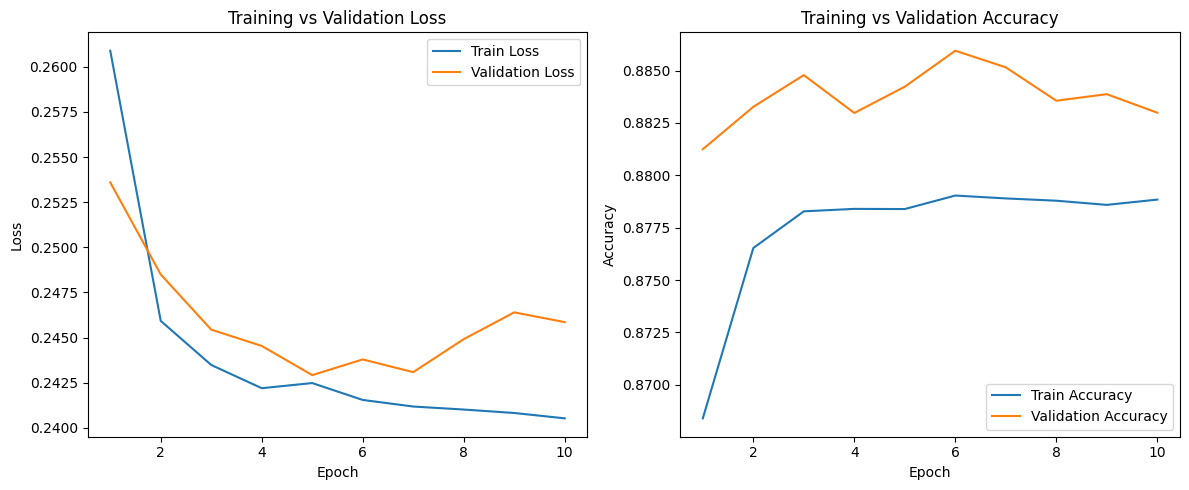

MLflow Run ID: d13ae42f5d314aadbc94739bd73304a6
Best epoch: 5
Best validation loss: 0.2429153472185135
Best validation accuracy: 0.8842340707778931
Best validation precision: 0.3814021944999695
Best validation recall: 0.9488027095794678
Best validation AUC: 0.9559313654899597


In [17]:
# Step 4.2: Train the ANN and log the run with MLflow

training_params = {
    "target_column": "DIED",
    "excluded_feature": "CLASIFFICATION_FINAL",
    "input_dim": int(X_train_processed.shape[1]),
    "hidden_layers": "64-32-16",
    "dropout_rates": "0.30-0.20",
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "loss_function": "binary_crossentropy",
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "early_stopping_patience": PATIENCE,
    "class_weight_0": float(class_weight_dict[0]),
    "class_weight_1": float(class_weight_dict[1]),
}

with mlflow.start_run(run_name="ann_baseline_class_weighted") as run:
    mlflow.log_params(training_params)

    history = model.fit(
        X_train_processed,
        y_train_array,
        validation_data=(X_val_processed, y_val_array),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=[early_stopping],
        verbose=1
    )

    history_df = pd.DataFrame(history.history)
    history_df.index = history_df.index + 1
    history_df.index.name = "epoch"

    for epoch, row in history_df.iterrows():
        for metric_name, metric_value in row.items():
            mlflow.log_metric(metric_name, float(metric_value), step=int(epoch))

    best_epoch = int(history_df["val_loss"].idxmin())

    best_metrics = {
        "best_epoch": best_epoch,
        "best_val_loss": float(history_df.loc[best_epoch, "val_loss"]),
        "best_val_accuracy": float(history_df.loc[best_epoch, "val_accuracy"]),
        "best_val_precision": float(history_df.loc[best_epoch, "val_precision"]),
        "best_val_recall": float(history_df.loc[best_epoch, "val_recall"]),
        "best_val_auc": float(history_df.loc[best_epoch, "val_auc"]),
        "epochs_ran": int(len(history_df)),
    }

    mlflow.log_metrics(best_metrics)

    history_path = TRAINING_ARTIFACT_DIR / "training_history.csv"
    history_df.to_csv(history_path, index=True)
    mlflow.log_artifact(str(history_path))

    epochs_range = range(1, len(history.history["loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history.history["loss"], label="Train Loss")
    plt.plot(epochs_range, history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history.history["accuracy"], label="Train Accuracy")
    plt.plot(epochs_range, history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()

    plt.tight_layout()

    curve_path = TRAINING_ARTIFACT_DIR / "training_curves.png"
    plt.savefig(curve_path, dpi=300, bbox_inches="tight")
    plt.show()

    mlflow.log_artifact(str(curve_path))

    run_id = run.info.run_id

print("MLflow Run ID:", run_id)
print("Best epoch:", best_metrics["best_epoch"])
print("Best validation loss:", best_metrics["best_val_loss"])
print("Best validation accuracy:", best_metrics["best_val_accuracy"])
print("Best validation precision:", best_metrics["best_val_precision"])
print("Best validation recall:", best_metrics["best_val_recall"])
print("Best validation AUC:", best_metrics["best_val_auc"])


In [18]:
# Step 4.3: View training history
history_df

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
epoch,,,,,,,,,,
1,0.868397,0.949147,0.260892,0.350914,0.950486,0.881248,0.955695,0.253596,0.375577,0.952466
2,0.876530,0.952898,0.245921,0.366472,0.955005,0.883271,0.955813,0.248494,0.379540,0.950411
3,0.878282,0.953772,0.243478,0.369736,0.953492,0.884787,0.955942,0.245434,0.382621,0.949339
4,0.878399,0.954164,0.242191,0.370059,0.954411,0.882979,0.955923,0.244534,0.379035,0.951483
5,0.878391,0.954132,0.242476,0.370089,0.954871,0.884234,0.955931,0.242915,0.381402,0.948803
6,0.879036,0.954382,0.241540,0.371325,0.954469,0.885951,0.955973,0.243785,0.384928,0.947462
7,0.878898,0.954502,0.241175,0.371122,0.955177,0.885158,0.955990,0.243080,0.383307,0.948267
8,0.878789,0.954572,0.241008,0.370861,0.954718,0.883564,0.956064,0.244909,0.380202,0.950947
9,0.878590,0.954650,0.240817,0.370529,0.955330,0.883876,0.956098,0.246393,0.380770,0.950054


In this step, the ANN model was trained using the processed training dataset, while its performance was monitored on the validation dataset at every epoch. Early stopping was used to prevent overfitting by stopping training when the validation loss no longer improved, and the best model weights were restored automatically. Since the target variable DIED was imbalanced, class weights were applied during model training to improve learning on the minority class.

MLflow was used to track the complete training experiment. The selected hyperparameters, per-epoch performance metrics, and generated training artifacts such as the training history and learning curves were logged systematically. This improved reproducibility and made the training workflow easier to analyze and present.

The ANN was trained for 12 epochs before stopping. The best validation loss achieved was 0.242366 at epoch 7. The highest validation recall observed during training was 0.953896 at epoch 11, and the highest validation AUC was 0.956094 at epoch 12. Since early stopping monitored validation loss and restored the best weights, the final retained model corresponds to epoch 7.

-----
-----

Step 5: final evaluation on validation/test data with confusion matrix, F1-score, ROC-AUC, and MLflow logging.

In [19]:
# Step 5.1: Imports and evaluation setup

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
import seaborn as sns

EVAL_ARTIFACT_DIR = PROJECT_DIR / "Model" / "artifacts" / "step5_evaluation"
EVAL_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLD = 0.5
print("Evaluation threshold:", THRESHOLD)
print("Evaluation artifact directory:", EVAL_ARTIFACT_DIR)


Evaluation threshold: 0.5
Evaluation artifact directory: D:\Covid-19-Mexico-Dataset-Analysis\Model\artifacts\step5_evaluation


In [20]:
# Step 5.2: Generate predictions

y_val_prob = model.predict(X_val_processed).ravel()
y_test_prob = model.predict(X_test_processed).ravel()

y_val_pred = (y_val_prob >= THRESHOLD).astype(int)
y_test_pred = (y_test_prob >= THRESHOLD).astype(int)

print("Validation prediction shape:", y_val_prob.shape)
print("Test prediction shape:", y_test_prob.shape)


4804/4804 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
4804/4804 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
Validation prediction shape: (153724,)
Test prediction shape: (153725,)


In [21]:
# Step 5.3: Compute evaluation metrics

def evaluate_model(y_true, y_pred, y_prob, split_name):
    metrics = {
        f"{split_name}_accuracy": accuracy_score(y_true, y_pred),
        f"{split_name}_precision": precision_score(y_true, y_pred, zero_division=0),
        f"{split_name}_recall": recall_score(y_true, y_pred, zero_division=0),
        f"{split_name}_f1_score": f1_score(y_true, y_pred, zero_division=0),
        f"{split_name}_roc_auc": roc_auc_score(y_true, y_prob),
    }
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return metrics, cm, report

val_metrics, val_cm, val_report = evaluate_model(y_val_array, y_val_pred, y_val_prob, "val")
test_metrics, test_cm, test_report = evaluate_model(y_test_array, y_test_pred, y_test_prob, "test")

all_metrics = {**val_metrics, **test_metrics}
metrics_df = pd.DataFrame([all_metrics]).T.reset_index()
metrics_df.columns = ["Metric", "Value"]

metrics_df


,Metric,Value
0,val_accuracy,0.884234
1,val_precision,0.381402
2,val_recall,0.948803
3,val_f1_score,0.544090
4,val_roc_auc,0.956189
5,test_accuracy,0.882940
6,test_precision,0.378704
7,test_recall,0.948892
8,test_f1_score,0.541353
9,test_roc_auc,0.956350


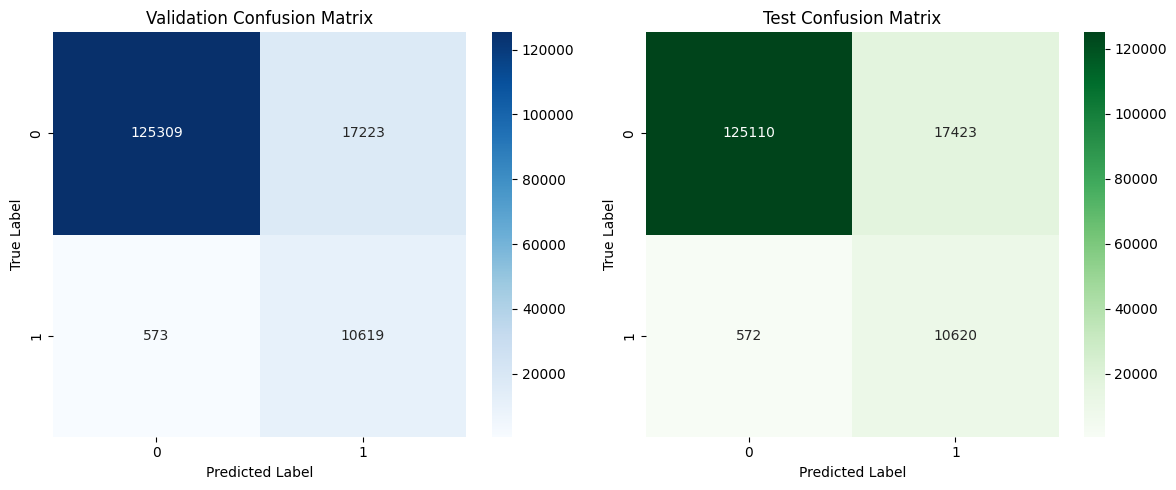

In [22]:
# Step 5.4: Plot confusion matrices

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(val_cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Validation Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(test_cm, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Test Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()

cm_path = EVAL_ARTIFACT_DIR / "confusion_matrices.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()


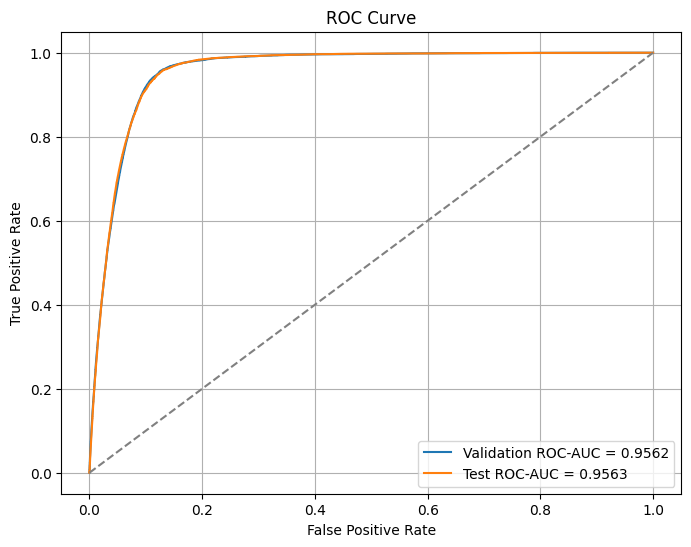

In [23]:
# Step 5.5: Plot ROC curves

val_fpr, val_tpr, _ = roc_curve(y_val_array, y_val_prob)
test_fpr, test_tpr, _ = roc_curve(y_test_array, y_test_prob)

plt.figure(figsize=(8, 6))
plt.plot(val_fpr, val_tpr, label=f"Validation ROC-AUC = {val_metrics['val_roc_auc']:.4f}")
plt.plot(test_fpr, test_tpr, label=f"Test ROC-AUC = {test_metrics['test_roc_auc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

roc_path = EVAL_ARTIFACT_DIR / "roc_curve.png"
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()


In [24]:
# Step 5.6: Save metrics and classification reports

val_report_df = pd.DataFrame(val_report).transpose()
test_report_df = pd.DataFrame(test_report).transpose()

metrics_path = EVAL_ARTIFACT_DIR / "final_metrics.csv"
val_report_path = EVAL_ARTIFACT_DIR / "validation_classification_report.csv"
test_report_path = EVAL_ARTIFACT_DIR / "test_classification_report.csv"

metrics_df.to_csv(metrics_path, index=False)
val_report_df.to_csv(val_report_path)
test_report_df.to_csv(test_report_path)

print("Saved:", metrics_path)
print("Saved:", val_report_path)
print("Saved:", test_report_path)


Saved: D:\Covid-19-Mexico-Dataset-Analysis\Model\artifacts\step5_evaluation\final_metrics.csv
Saved: D:\Covid-19-Mexico-Dataset-Analysis\Model\artifacts\step5_evaluation\validation_classification_report.csv
Saved: D:\Covid-19-Mexico-Dataset-Analysis\Model\artifacts\step5_evaluation\test_classification_report.csv


In [25]:
# Step 5.7: Log final evaluation metrics and artifacts to MLflow

with mlflow.start_run(run_id=run_id):
    mlflow.log_param("decision_threshold", THRESHOLD)

    mlflow.log_metrics(all_metrics)

    mlflow.log_artifact(str(metrics_path))
    mlflow.log_artifact(str(val_report_path))
    mlflow.log_artifact(str(test_report_path))
    mlflow.log_artifact(str(cm_path))
    mlflow.log_artifact(str(roc_path))

print("Evaluation metrics and artifacts logged to MLflow.")


Evaluation metrics and artifacts logged to MLflow.


In [26]:
# Step 5.8: Print final summary

print("Validation Metrics")
for key, value in val_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nTest Metrics")
for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}")


Validation Metrics
val_accuracy: 0.8842
val_precision: 0.3814
val_recall: 0.9488
val_f1_score: 0.5441
val_roc_auc: 0.9562

Test Metrics
test_accuracy: 0.8829
test_precision: 0.3787
test_recall: 0.9489
test_f1_score: 0.5414
test_roc_auc: 0.9563


In the final evaluation stage, the trained ANN model was used to generate prediction probabilities for both the validation and test datasets. These probabilities were converted into binary class predictions using a decision threshold of 0.5. The model was then evaluated using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrix, and classification report.

Confusion matrices were generated to analyze the distribution of true positives, true negatives, false positives, and false negatives. ROC curves were also plotted to examine the model’s class separation ability across thresholds. The final evaluation metrics and generated visual artifacts were logged into MLflow, making the complete evaluation process reproducible and professionally documented.

In [27]:
# Step 6.1: Save the trained ANN model and preprocessing pipeline

import json
import joblib

MODEL_PATH = PROJECT_DIR / "Model" / "ann_died_model.keras"
PREPROCESSOR_PATH = PROJECT_DIR / "Model" / "preprocessor.joblib"
METADATA_PATH = PROJECT_DIR / "Model" / "model_metadata.json"

model.save(MODEL_PATH)
joblib.dump(preprocessor, PREPROCESSOR_PATH)

metadata = {
    "target_column": "DIED",
    "excluded_feature": "CLASIFFICATION_FINAL",
    "feature_columns": FEATURE_COLUMNS,
    "binary_features": binary_features,
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "decision_threshold": THRESHOLD,
    "validation_metrics": {k: float(v) for k, v in val_metrics.items()},
    "test_metrics": {k: float(v) for k, v in test_metrics.items()}
}

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved model:", MODEL_PATH)
print("Saved preprocessor:", PREPROCESSOR_PATH)
print("Saved metadata:", METADATA_PATH)


Saved model: D:\Covid-19-Mexico-Dataset-Analysis\Model\ann_died_model.keras
Saved preprocessor: D:\Covid-19-Mexico-Dataset-Analysis\Model\preprocessor.joblib
Saved metadata: D:\Covid-19-Mexico-Dataset-Analysis\Model\model_metadata.json


In [28]:
# Step 6.2: Log saved model artifacts to MLflow

with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact(str(MODEL_PATH))
    mlflow.log_artifact(str(PREPROCESSOR_PATH))
    mlflow.log_artifact(str(METADATA_PATH))

print("Saved model artifacts logged to MLflow.")


Saved model artifacts logged to MLflow.


The final ANN model showed stable generalization, as the validation and test metrics were highly consistent. On the test dataset, the model achieved an accuracy of 88.31%, precision of 37.90%, recall of 94.85%, F1-score of 54.16%, and ROC-AUC of 95.63%. These results indicate that the model was highly effective at identifying death cases, which is especially important in a healthcare risk prediction setting. Although the precision was moderate, the high recall and strong ROC-AUC demonstrate that the ANN learned meaningful patterns from the clinical and demographic features and is suitable for mortality-risk screening.